In [32]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 
from sklearn.naive_bayes import GaussianNB 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier

In [3]:
df=pd.read_csv("Preprocessed_Dataset_For_Prediction.csv")

In [6]:
df.head()

,Unnamed: 0,mrr_amount,seats,upgrade_flag,downgrade_flag,churn_flag,auto_renew_flag,usage_count,error_count,error_rate,resolution_time_hours,satisfaction_score,escalation_flag,no_feedback,no_ticket
0,0,3350.600000,34.200000,3,0,False,0.900000,514,27,0.052427,31.750000,4.000000,0.0,0,0
1,1,1569.000000,15.333333,0,1,False,0.888889,602,31,0.051410,33.000000,3.964163,0.0,1,0
2,2,678.333333,25.833333,1,0,False,0.833333,364,22,0.060274,32.000000,3.000000,0.0,0,0
3,3,1501.454545,20.454545,3,0,True,0.545455,490,21,0.042770,30.333333,4.000000,0.0,0,0
4,4,928.111111,13.666667,1,0,True,0.666667,562,30,0.053286,10.000000,3.000000,0.0,0,0


In [7]:
df = pd.get_dummies(df, drop_first=True)

In [8]:
df.head()

,Unnamed: 0,mrr_amount,seats,upgrade_flag,downgrade_flag,churn_flag,auto_renew_flag,usage_count,error_count,error_rate,resolution_time_hours,satisfaction_score,escalation_flag,no_feedback,no_ticket
0,0,3350.600000,34.200000,3,0,False,0.900000,514,27,0.052427,31.750000,4.000000,0.0,0,0
1,1,1569.000000,15.333333,0,1,False,0.888889,602,31,0.051410,33.000000,3.964163,0.0,1,0
2,2,678.333333,25.833333,1,0,False,0.833333,364,22,0.060274,32.000000,3.000000,0.0,0,0
3,3,1501.454545,20.454545,3,0,True,0.545455,490,21,0.042770,30.333333,4.000000,0.0,0,0
4,4,928.111111,13.666667,1,0,True,0.666667,562,30,0.053286,10.000000,3.000000,0.0,0,0


In [14]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [15]:
df.head()

,mrr_amount,seats,upgrade_flag,downgrade_flag,churn_flag,auto_renew_flag,usage_count,error_count,error_rate,resolution_time_hours,satisfaction_score,escalation_flag,no_feedback,no_ticket
0,3350.600000,34.200000,3,0,False,0.900000,514,27,0.052427,31.750000,4.000000,0.0,0,0
1,1569.000000,15.333333,0,1,False,0.888889,602,31,0.051410,33.000000,3.964163,0.0,1,0
2,678.333333,25.833333,1,0,False,0.833333,364,22,0.060274,32.000000,3.000000,0.0,0,0
3,1501.454545,20.454545,3,0,True,0.545455,490,21,0.042770,30.333333,4.000000,0.0,0,0
4,928.111111,13.666667,1,0,True,0.666667,562,30,0.053286,10.000000,3.000000,0.0,0,0


In [19]:
X = df.drop('churn_flag', axis=1)
y = df['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
#Feature scaling (for safety)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [22]:
#Train model (Improved Random Forest)
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [23]:
#Predictions
y_pred = model.predict(X_test)

In [27]:
# Generate confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("📊 Confusion Matrix:\n", cm)

📊 Confusion Matrix:
 [[11 27]
 [10 52]]


In [33]:
#Evaluation
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📄 Classification Report:\n", classification_report(y_test, y_pred))
print("🔥 ROC-AUC Score:", roc_auc_score(y_test, y_pred))

✅ Accuracy: 0.63

📊 Confusion Matrix:
 [[11 27]
 [10 52]]

📄 Classification Report:
               precision    recall  f1-score   support

       False       0.52      0.29      0.37        38
        True       0.66      0.84      0.74        62

    accuracy                           0.63       100
   macro avg       0.59      0.56      0.56       100
weighted avg       0.61      0.63      0.60       100

🔥 ROC-AUC Score: 0.5640916808149405


In [36]:
#Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\n🔝 Feature Importance:\n")
print(importance)


🔝 Feature Importance:

usage_count              0.148642
seats                    0.128308
mrr_amount               0.116036
error_count              0.113734
error_rate               0.112393
resolution_time_hours    0.108230
auto_renew_flag          0.096142
satisfaction_score       0.068822
upgrade_flag             0.039206
downgrade_flag           0.025415
escalation_flag          0.023589
no_feedback              0.019483
no_ticket                0.000000
dtype: float64


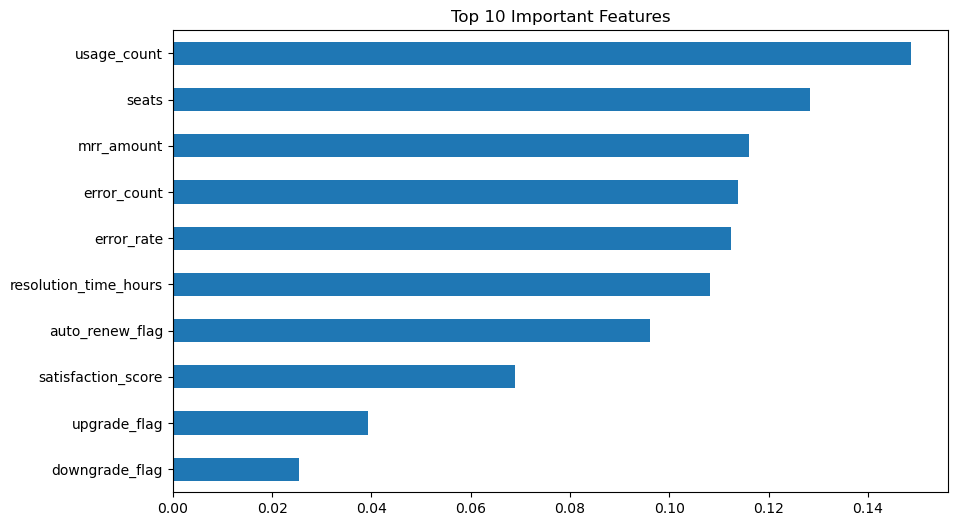

In [37]:
# Optional: visualize feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [39]:
df['usage_per_seat'] = df['usage_count'] / (df['seats'] + 1)
df['error_per_usage'] =df['error_count'] / (df['usage_count'] + 1)
df['mrr_per_seat'] = df['mrr_amount'] / (df['seats'] + 1)

In [41]:
df = df.drop(columns=['no_ticket'])

In [42]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(random_state=42)

In [43]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [44]:
y_prob = model.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.6).astype(int)

NotFittedError: need to call fit or load_model beforehand